# Reproducibility and Analysis Overview

This notebook presents a reproducible time series analysis of the overall U.S. unemployment rate and the youth unemployment rate in the United States. The goal is to compare these two series in terms of volatility, cyclical behavior, and post-shock recovery over time using tools for time series analysis.

## Structure of the notebook

This notebook is organized to connect the code directly to the analytical questions being studied. Each major section includes brief narrative explanations describing the purpose of the analysis, the methods being applied, and how the results relate to the research question.

All preprocessing, analysis, and visualization steps needed to reproduce the results from the raw data are included here. The notebook documents how the data are obtained, cleaned, and preprocessed for time-series analysis. 

The notebook also includes appropriate diagnostic and validation steps for the methods used. These checks are included to ensure that conclusions are supported by the assumptions of the methods.

## Reseach question

How do unemployment dynamics differ across U.S. age groups in terms of volatility, persistence, and cyclical behavior over time? In this case, age groups are defined by the following age intervals: youth (16–24 yrs), prime (25-54 yrs), and older workers (55 yrs over). 

Here, we also define the following research goals:
Volatility: How much each unemployment series changes from month to month. In economics, this captures how sensitive each group is to expansions and recessions.
Persistence: How long do the effects of a labor market shock last once unemployment increases? In economics, this reflects how quickly displaced workers are reabsorbed. 
Cyclical Patterns: How each series behaves over business cycles. In economics, different cyclical patterns would suggest that youth and overall unemployment are affected differently by macroeconomic factors.

We also need to clearly define unemployment and unemployment rate here. Using the definition from the Bureau of Labor Statistics (BLS) and Current Population Survey (CPS), a person is "unemployed" if the subject was not employed during the survey reference week and either actively looked for work during the last 4 weeks or was on temporary layoff. People waiting to start a new job are counted as unemployed only if they also looked for work in the last 4 weeks. The definition does not depend on whether someone receives unemployment insurance. And the unemployment rate is the number of unemployed people as a percentage of the labor force, where the labor force is employed + unemployed.

$$
\text{Unemployment Rate} = \frac{\text{Unemployed}}{\text{Labor Force}} \times 100
$$

I revised my initial question proposal to include other age groups based on the advide from Professor Liberty Hamilton's comment to address a richer question that, are labor-market dynamics different across age groups, rather than just between youth and the aggregate? The new, broader age-heterogeneity question avoids the weakness of using an aggregate as the only comparison and still fits the methods that I already planned out. I may still include the overall unemployment rate as a benchmark in descriptive plots, but the main analysis will focus on age-specific dynamics.

## Data

The data we will be using consists of four national monthly time series: the overall U.S. unemployment rate (UNRATE), the youth unemployment rate for ages 16–24 (LNS14024887), the prime-age workers unemployment rate for ages 25-54 (LNS14000060), and older workers unemployment rate for ages over 55 years old (LNS14024230), where the employment rate measures the share of the relevant labor force that is unemployed. All series come from the Current Population Survey (CPS), a monthly survey jointly sponsored by the U.S. Bureau of Labor Statistics and the U.S. Census Bureau. The data can be accessed through the Federal Reserve Economic Data (FRED) database. All series are seasonally adjusted and are reported as monthly percentages. Additionally, all series run from January 1948 to April 2026, giving 939 monthly observations. Thus, the analysis can use a matched sample of 940 time points for each series. In conclusion, our dataset contains four distinct but related time series observed at the same temporal resolution.

In the following code section, we will perform the data loading, cleaning, and preprocessing steps for time series analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the four datasets
overall = pd.read_csv("../data/UNRATE_overall.csv")
youth   = pd.read_csv("../data/UNRATE_youth.csv")
prime   = pd.read_csv("../data/UNRATE_prime.csv")
older   = pd.read_csv("../data/UNRATE_older.csv")


# rename columns
overall = overall.rename(columns={
    "observation_date": "date",
    "UNRATE": "overall"
})

youth = youth.rename(columns={
    "observation_date": "date",
    "LNS14024887": "youth_16_24"
})

prime = prime.rename(columns={
    "observation_date": "date",
    "LNS14000060": "prime_25_54"
})

older = older.rename(columns={
    "observation_date": "date",
    "LNS14024230": "older_55_plus"
})

for df in [overall, youth, prime, older]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)

# merge datasets
df = (
    overall
    .merge(youth, on="date", how="inner", validate="one_to_one")
    .merge(prime, on="date", how="inner", validate="one_to_one")
    .merge(older, on="date", how="inner", validate="one_to_one")
    .sort_values("date")
)

# set time index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# set monthly frequency
df = df.asfreq("MS") 

# basic checks
print(df.head(5))
print(df.isna().sum())
print("Sample start:", df.index.min())
print("Sample end:  ", df.index.max())
print("Number of observations:", len(df))

expected_index = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Missing timestamps relative to full monthly grid:",

      expected_index.difference(df.index))

            overall  youth_16_24  prime_25_54  older_55_plus
date                                                        
1948-01-01      3.4          6.8          2.5            2.9
1948-02-01      3.8          7.7          2.9            3.1
1948-03-01      4.0          8.7          2.8            3.0
1948-04-01      3.9          7.8          3.0            3.0
1948-05-01      3.5          6.7          2.7            3.1
overall          1
youth_16_24      1
prime_25_54      1
older_55_plus    1
dtype: int64
Sample start: 1948-01-01 00:00:00
Sample end:   2026-04-01 00:00:00
Number of observations: 940
Missing timestamps relative to full monthly grid: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [2]:
df[df.isna().any(axis=1)]

,overall,youth_16_24,prime_25_54,older_55_plus
date,,,,
2025-10-01,NaN,NaN,NaN,NaN


In [3]:
df = df.dropna()

expected_index = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Missing timestamps relative to full monthly grid:",
      expected_index.difference(df.index))

Missing timestamps relative to full monthly grid: DatetimeIndex(['2025-10-01'], dtype='datetime64[ns]', freq='MS')


We loaded the four monthly unemployment-rate datasets for the overall labor force, youth workers, prime-age workers, and older workers from CSV files in the repo data folder, standardized the variable names, and converted the date column to a proper datetime format. We then merged the four files into a single dataframe by date, sorted the observations chronologically, and set the date variable as the time index so the data could be handled as monthly time series. After assigning an explicit monthly frequency, we checked for duplicate dates, missing values, and gaps in the monthly calendar. This revealed that October 2025 was missing for all four series, which reflects a genuine gap in the CPS source data rather than a coding error. BLS says CPS data were not collected for October 2025 due to the lapse in appropriations, were not collected retroactively, and no October 2025 Employment Situation release was issued. Because this month was not observed in the original data and our planned methods rely on the actual temporal dependence structure of the series, we dropped that month rather than imputing it, since filling it in artificially could distort spectral patterns, ARIMA dependence estimates, and lagged relationships. After removing that missing month, the series were aligned on a common sample from January 1948 to through April 2026 and were ready for downstream time-series analysis.

## Exploratory Data Analysis (EDA)

(939, 4)
          overall  youth_16_24  prime_25_54  older_55_plus
count  939.000000   939.000000   939.000000     939.000000
mean     5.660809    11.572950     4.539936       3.781257
std      1.704652     2.909618     1.537135       1.186172
min      2.500000     4.800000     1.900000       1.700000
25%      4.300000     9.600000     3.400000       3.000000
50%      5.500000    11.500000     4.300000       3.500000
75%      6.700000    13.100000     5.500000       4.300000
max     14.800000    27.500000    12.800000      13.600000


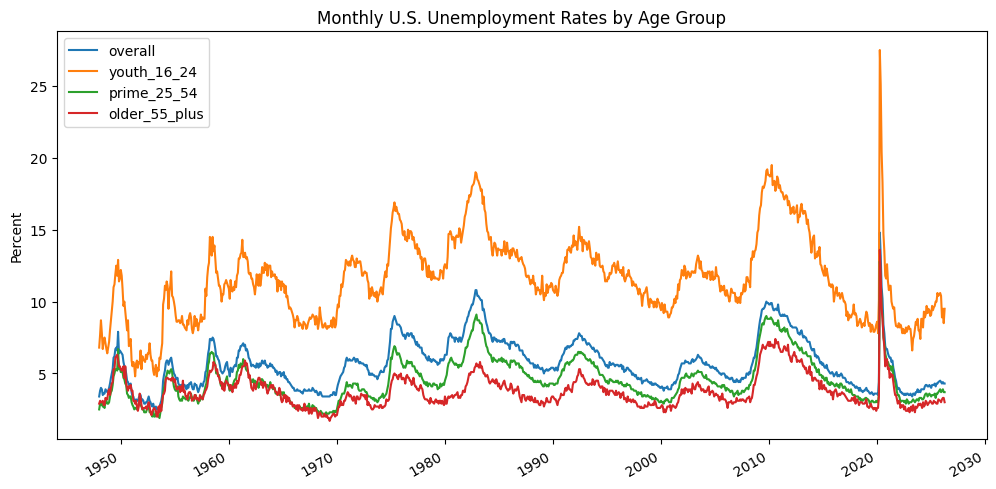

In [4]:
print(df.shape)
print(df.describe())

df.plot(figsize=(12, 6))
plt.title("Monthly U.S. Unemployment Rates by Age Group")
plt.ylabel("Percent")
plt.xlabel("")
plt.show()

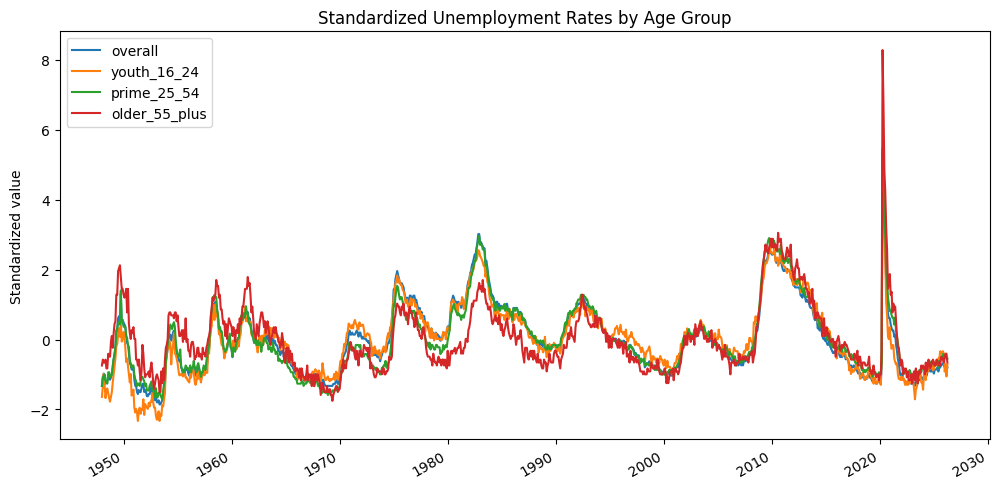

In [5]:
df_z = (df - df.mean()) / df.std()

df_z.plot(figsize=(12, 6))
plt.title("Standardized Unemployment Rates by Age Group")
plt.ylabel("Standardized value")
plt.xlabel("")
plt.show()

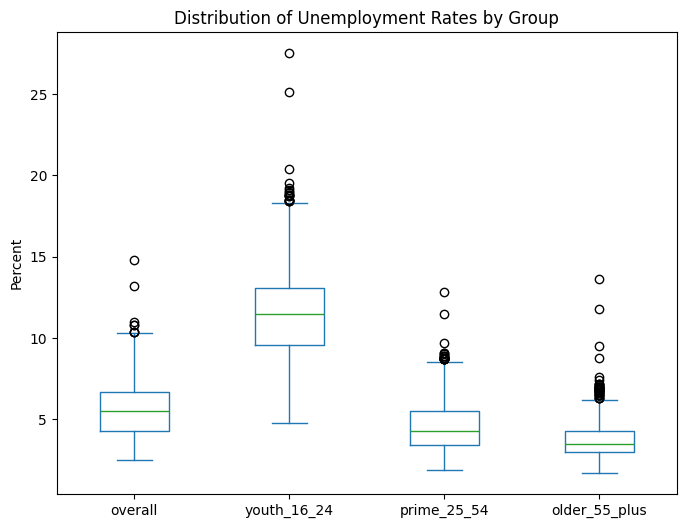

In [6]:
df.plot(kind="box", figsize=(8, 6))
plt.title("Distribution of Unemployment Rates by Group")
plt.ylabel("Percent")
plt.show()

Looking at summary and descriptive statistics, youth unemployment is consistently much higher than the other series and also shows the widest spread, indicating substantially greater variability over time. Prime-age unemployment generally lies below the overall rate, while older-worker unemployment is usually the lowest, with a tighter interquartile range and lower typical values. All four series show outliers associated with major downturns, especially the pandemic spike, but the extreme values are much more pronounced for youth unemployment.

The standardized plot adds an important qualification that although the level of youth unemployment is much higher, the broad cyclical movements are quite similar across groups. The series rise and fall together around major recessions, suggesting strong common business-cycle exposure, but the magnitude differs by age group. In particular, the COVID-era spike stands out as unusually large for all groups. Overall, the figures suggest that age groups share common macroeconomic cycles, but differ meaningfully in typical level and variability, with youth unemployment appearing especially elevated and volatile.

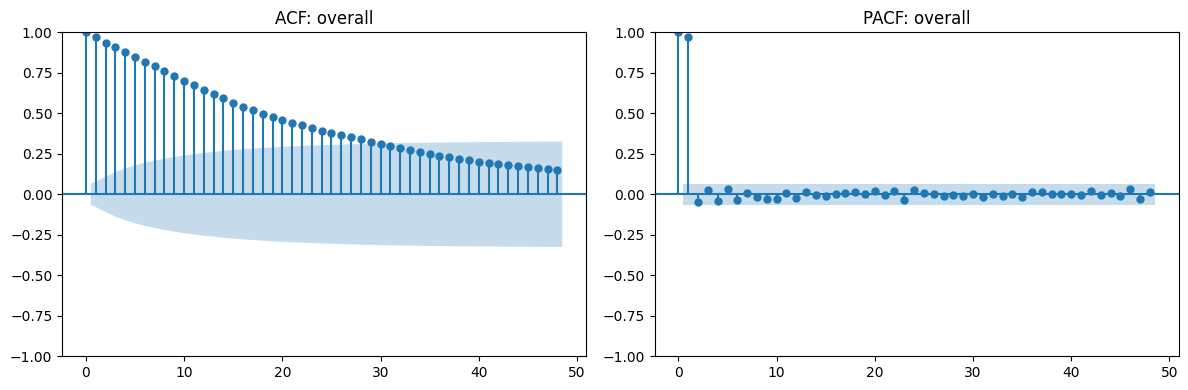

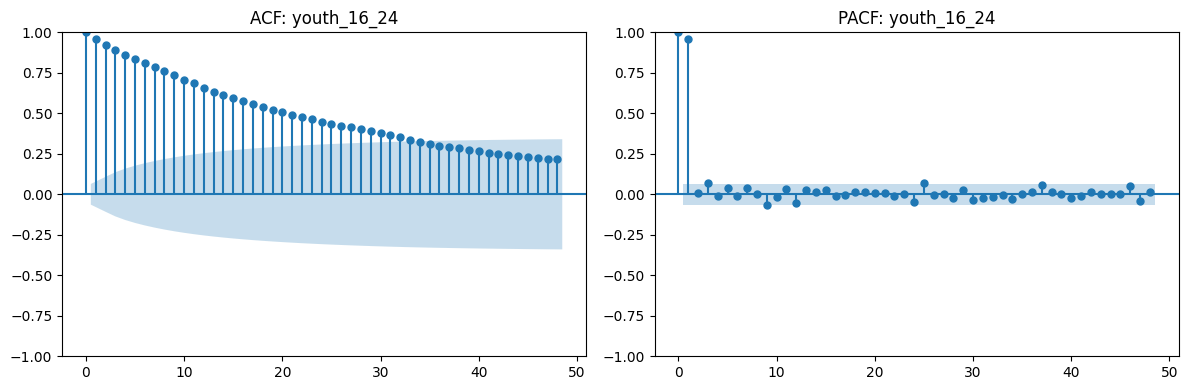

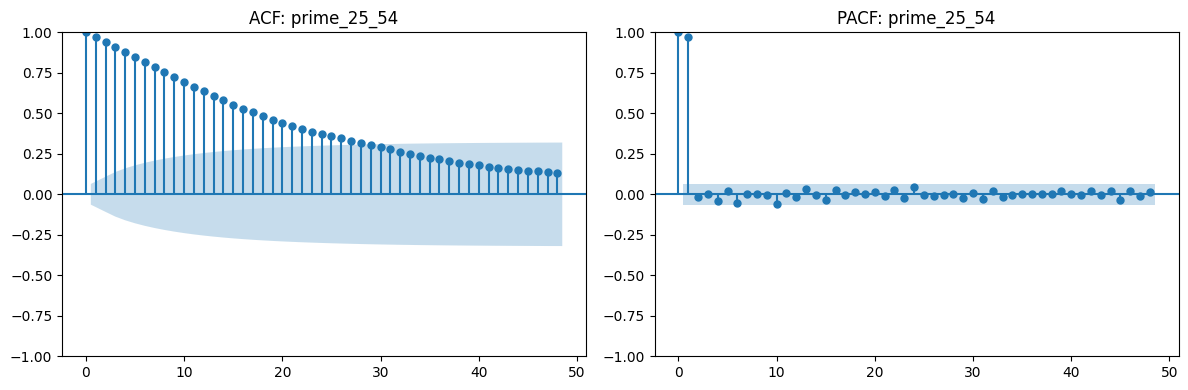

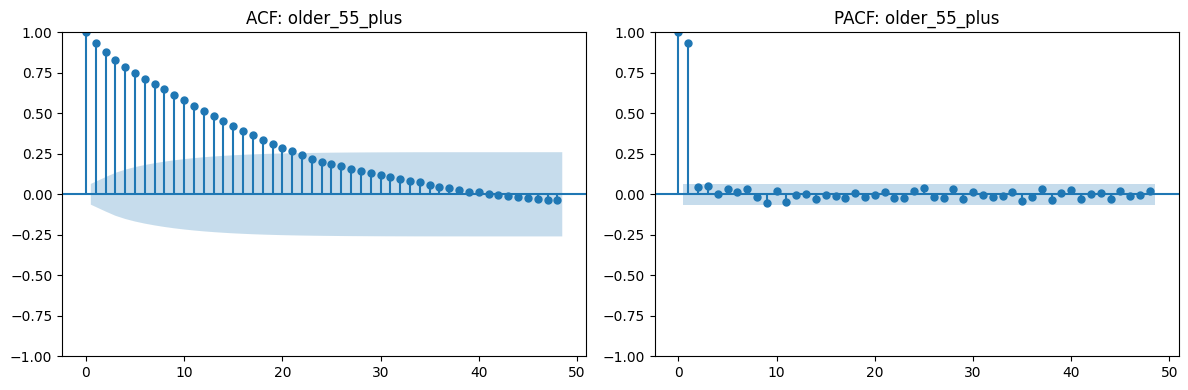

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(df[col].dropna(), ax=axes[0], lags=48)
    plot_pacf(df[col].dropna(), ax=axes[1], lags=48, method="ywm")
    axes[0].set_title(f"ACF: {col}")
    axes[1].set_title(f"PACF: {col}")
    plt.tight_layout()
    plt.show()

The ACF and PACF plots show a very consistent pattern across all four unemployment series. In every case, the ACF starts near 1 and declines only gradually over many lags, which indicates strong serial dependence and substantial persistence in unemployment over time. This means that current unemployment is highly related to recent past unemployment, and shocks tend to dissipate slowly rather than disappearing after only a few months. The youth series appears somewhat more persistent at longer lags than the others, while the older-worker series declines a bit faster and eventually approaches zero slightly earlier.

The PACF plots shows that each series exhibits one dominant spike at lag 1, while nearly all subsequent lags lie close to zero and mostly within the confidence bands. This pattern of strong first-order dependence is similar to an AR(1) process. At the same time, The very slow decay of the ACF in levels suggests that the unemployment series may be highly persistent or possibly nonstationary, so formal stationarity checks are needed before deciding whether to model the data in levels or in transformed form such as first differences.

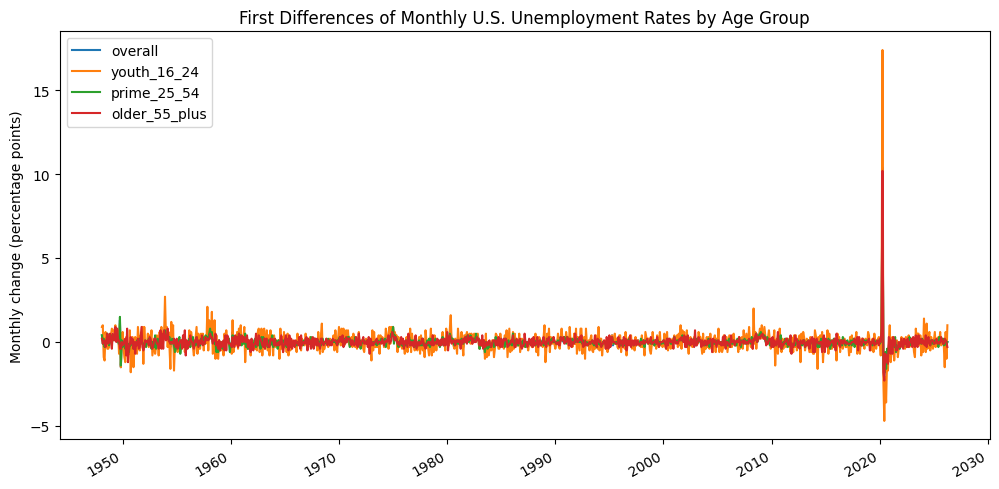

In [8]:
df_diff = df.diff().dropna()

df_diff.plot(figsize=(12, 6))
plt.title("First Differences of Monthly U.S. Unemployment Rates by Age Group")
plt.ylabel("Monthly change (percentage points)")
plt.xlabel("")
plt.show()

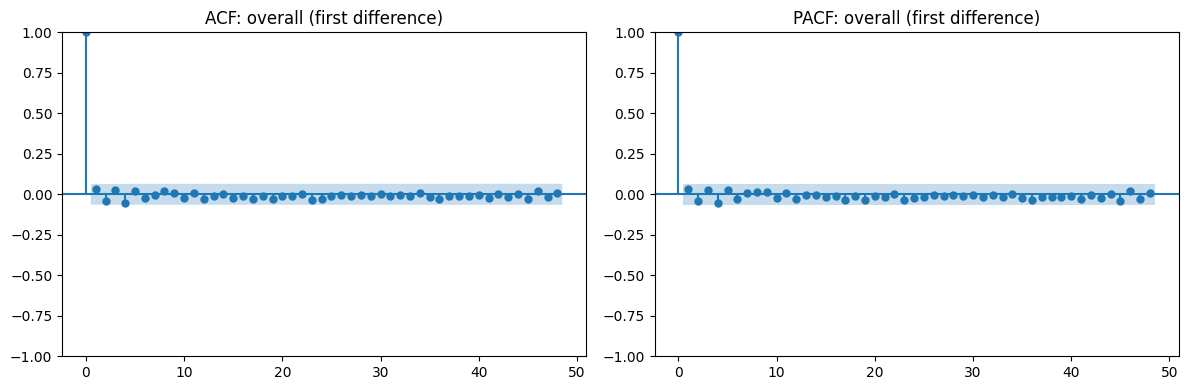

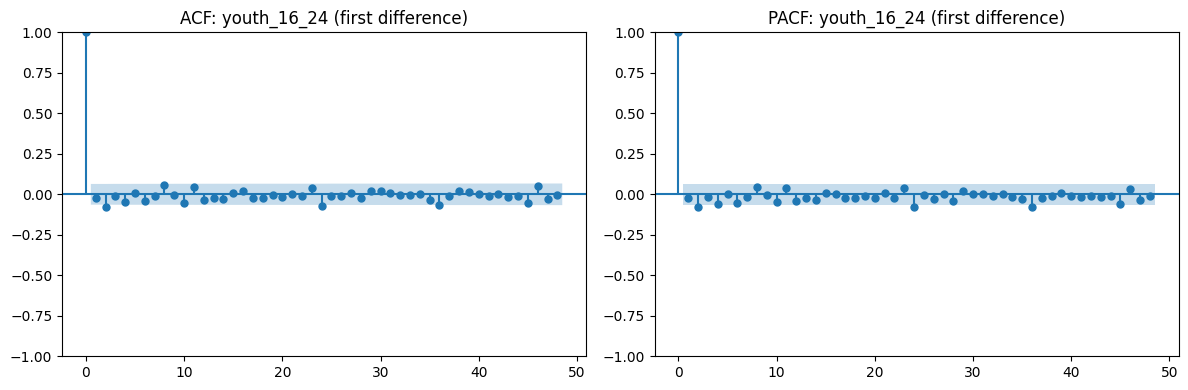

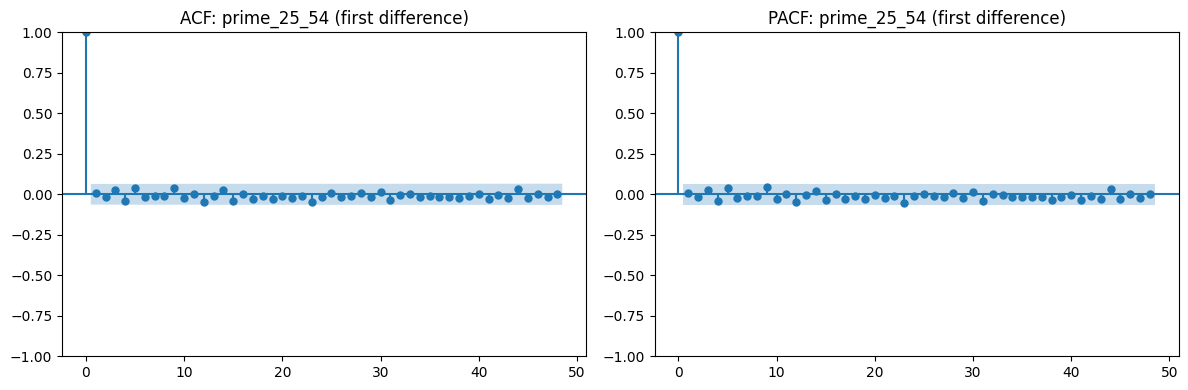

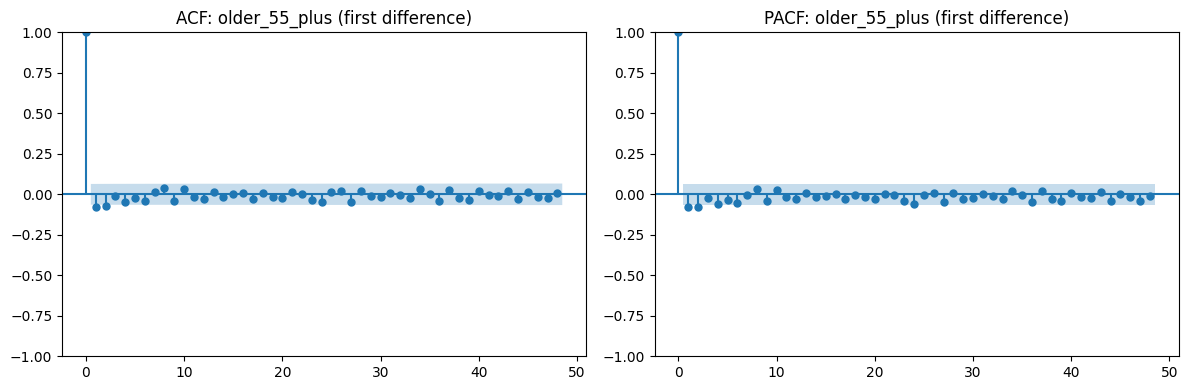

In [9]:
for col in df_diff.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(df_diff[col], ax=axes[0], lags=48)
    plot_pacf(df_diff[col], ax=axes[1], lags=48, method="ywm")
    axes[0].set_title(f"ACF: {col} (first difference)")
    axes[1].set_title(f"PACF: {col} (first difference)")
    plt.tight_layout()
    plt.show()

After differencing, the strong persistence seen in the level series largely disappears. In the plots, the monthly changes fluctuate around zero rather than showing the long, smooth business-cycle swings present in the original unemployment rates. This suggests that much of the dependence in the level series came from gradual rises and falls over time, rather than from strong serial structure in the month-to-month changes themselves.

The ACF and PACF of the differenced series support this interpretation. For all four age groups, nearly all autocorrelations and partial autocorrelations lie close to zero and within the confidence bands, with only a few small negative values at very short lags. This means that once we move from unemployment levels to monthly changes, there is little remaining temporal dependence.

The above evidence means unemployment levels are highly persistent, but the changes in unemployment are much less predictable from recent past changes. The main exceptions are the very large spikes around COVID 2020, especially for youth unemployment, which show that extreme macroeconomic shocks still dominate the differenced series. Youth unemployment also appears to have the largest first-difference swings in magnitude, consistent with the earlier evidence that it is the most volatile group.

The preliminary exploratory analysis shows that unemployment rates differ substantially across age groups in level and variability, while also sharing common cyclical movements. The level series are highly persistent, but much of this persistence is removed after first differencing, suggesting that transformed series may be more appropriate for modeling short-run dynamics. We now turn to the main time-series methods to study cyclical structure, persistence, and dynamic relationships more formally.

## Spectral Analysis
Since one of the central questions is whether unemployment differs across age groups in cyclical behavior, we begin with spectral analysis to compare the frequency structure of the series. 

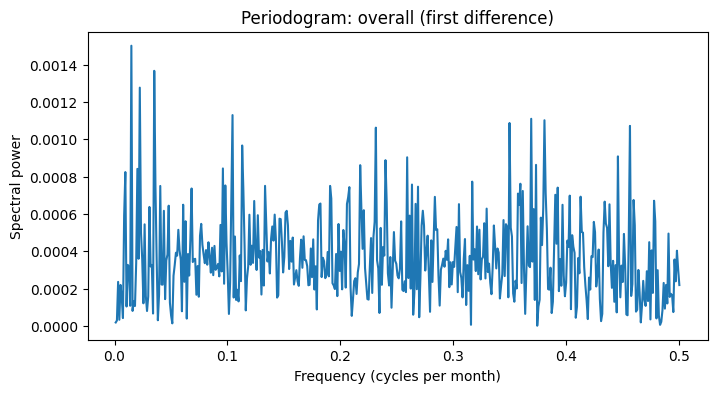

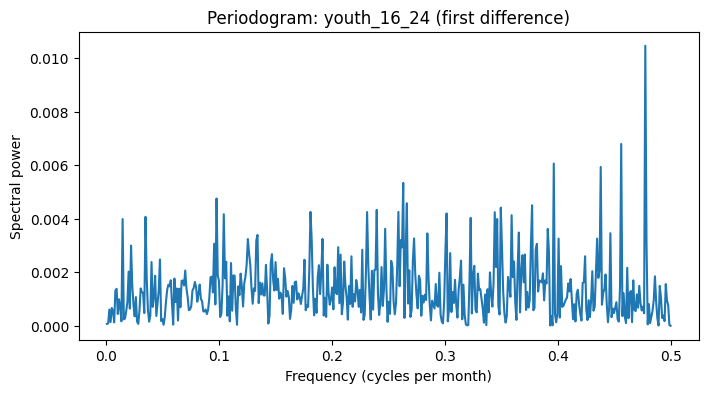

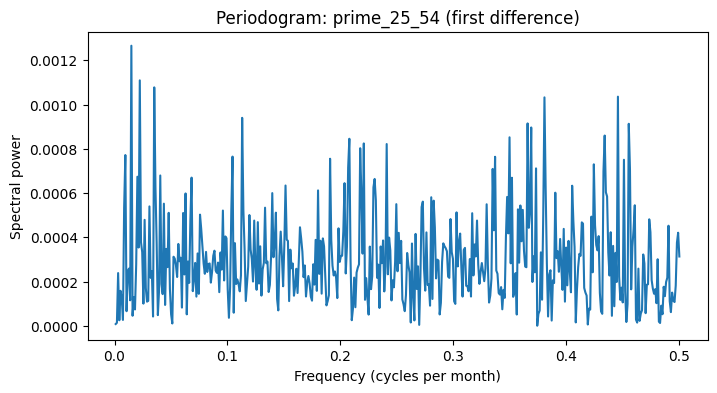

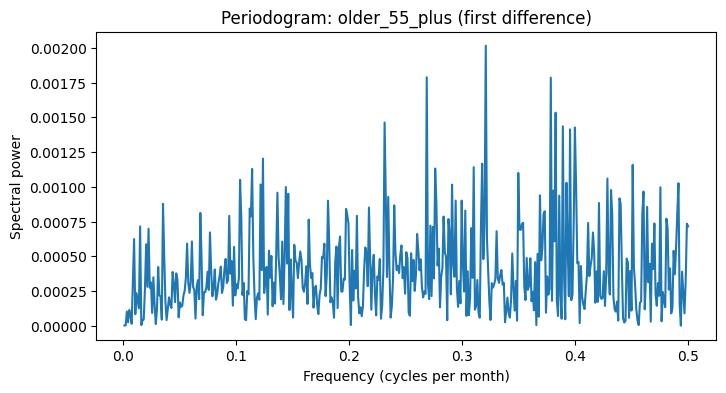

In [10]:
from scipy.signal import periodogram

def plot_periodogram(series, title, fs=1):
    """
    series: pandas Series
    fs: sampling frequency 
    """
    x = series.dropna().values
    freqs, power = periodogram(x, fs=fs, detrend="constant", scaling="spectrum")

    plt.figure(figsize=(8, 4))
    plt.plot(freqs[1:], power[1:])   # omit zero frequency
    plt.title(title)
    plt.xlabel("Frequency (cycles per month)")
    plt.ylabel("Spectral power")
    plt.show()

for col in df_diff.columns:
    plot_periodogram(df_diff[col], f"Periodogram: {col} (first difference)")

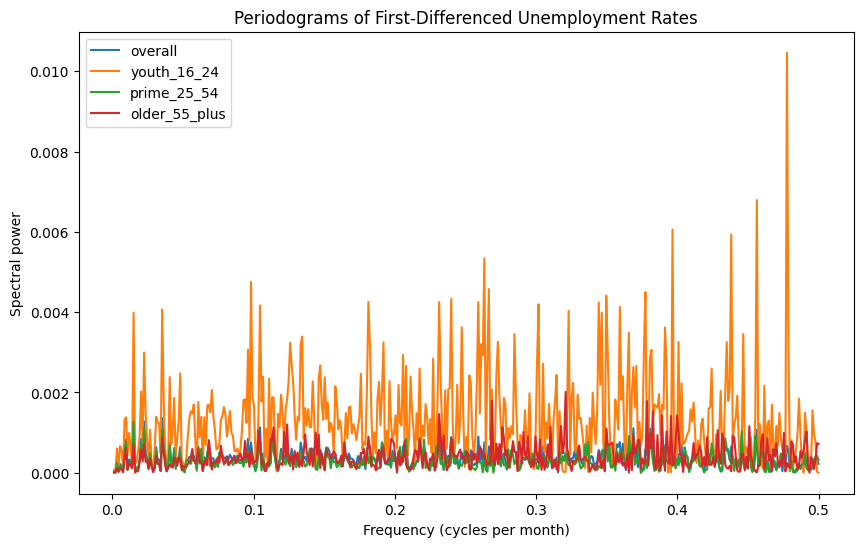

In [11]:
plt.figure(figsize=(10, 6))

for col in df_diff.columns:
    freqs, power = periodogram(
        df_diff[col].dropna().values,
        fs=1,
        detrend="constant",
        scaling="spectrum"
    )
    plt.plot(freqs[1:], power[1:], label=col)

plt.title("Periodograms of First-Differenced Unemployment Rates")
plt.xlabel("Frequency (cycles per month)")
plt.ylabel("Spectral power")
plt.legend()
plt.show()

**Scientific Interpretation** 
The first-differenced unemployment series do not show one clean dominant cycle. The periodograms are fairly noisy, with many local peaks rather than one sharp concentration of power at a particular frequency. This suggests the month-to-month changes in unemployment are not driven by a single stable periodic pattern. Instead, the differenced series look more like short-run fluctuations with occasional large macro shocks.

First, after differencing, there is not much evidence of a strong low-frequency component dominating the spectrum. This is consistent with what we already saw in the first differenced ACF/PACF plots, where once the long-run persistence is removed, the remaining series have relatively weak serial structure.

Second, the youth unemployment series has clearly larger spectral power overall than the others. In the combined plot, the youth line sits above the rest over much of the frequency range and has the most extreme spikes. This also matches our earlier observation that youth unemployment is the most volatile series. Even after differencing, its month-to-month changes remain larger in magnitude than those of other age groups.

Third, some of the large sharp peaks, especially for youth, are likely being driven by isolated extreme events such as the COVID-era shock rather than by a stable repeating cycle. A periodogram can be very sensitive to unusually large jumps, and the first-difference plots showed exactly such jumps around 2020.

Fourth, the overall, prime-age, and older worker series look broadly similar in shape, with relatively low and scattered spectral power. This suggests that the key difference across age groups may be strength of short-run fluctuations, not fundamentally different repeating frequencies.

Overall, with respect to cyclical behavior, the first-differenced data do not show strong evidence that age groups differ in their dominant repeating frequencies. Instead, they differ mainly in the magnitude of short-run variation, with youth unemployment standing out as the most volatile.

## ARIMA Modeling

Having examined the frequency-domain behavior of the differenced unemployment series, we now turn to ARIMA modeling to study their time-domain dependence. While the periodograms suggest that short-run changes are not dominated by a single stable cycle, ARIMA models allow us to assess how much serial dependence remains in each series and whether that dependence differs across age groups.

In [12]:
from statsmodels.tsa.arima.model import ARIMA

# candidate ARIMA orders 
candidate_orders = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)
]

# store best model info
arima_results = {}
summary_rows = []

for col in df.columns:
    print(f"\n--- {col} ---")
    
    # remove date index for ARIMA fitting
    series = df[col].reset_index(drop=True)
    
    best_aic = np.inf
    best_result = None
    best_order = None
    
    for order in candidate_orders:
        try:
            model = ARIMA(series, order=order)
            result = model.fit()
            
            print(f"ARIMA{order}: AIC = {result.aic:.2f}, BIC = {result.bic:.2f}")
            
            if result.aic < best_aic:
                best_aic = result.aic
                best_result = result
                best_order = order
                
        except Exception as e:
            print(f"ARIMA{order} failed: {e}")
    
    arima_results[col] = {
        "order": best_order,
        "result": best_result
    }
    
    summary_rows.append({
        "series": col,
        "best_order": best_order,
        "AIC": best_result.aic if best_result is not None else np.nan,
        "BIC": best_result.bic if best_result is not None else np.nan
    })

# summary table
arima_summary = pd.DataFrame(summary_rows)
print("\nBest ARIMA model by series:")
print(arima_summary)


--- overall ---
ARIMA(1, 1, 0): AIC = 1008.10, BIC = 1017.79
ARIMA(0, 1, 1): AIC = 1007.99, BIC = 1017.67
ARIMA(1, 1, 1): AIC = 1004.58, BIC = 1019.11

--- youth_16_24 ---
ARIMA(1, 1, 0): AIC = 2243.14, BIC = 2252.83
ARIMA(0, 1, 1): AIC = 2243.04, BIC = 2252.73
ARIMA(1, 1, 1): AIC = 2231.47, BIC = 2246.00

--- prime_25_54 ---
ARIMA(1, 1, 0): AIC = 821.77, BIC = 831.46
ARIMA(0, 1, 1): AIC = 821.77, BIC = 831.45
ARIMA(1, 1, 1): AIC = 820.35, BIC = 834.88

--- older_55_plus ---
ARIMA(1, 1, 0): AIC = 1084.50, BIC = 1094.19
ARIMA(0, 1, 1): AIC = 1083.48, BIC = 1093.17
ARIMA(1, 1, 1): AIC = 1064.50, BIC = 1079.04

Best ARIMA model by series:
          series best_order          AIC          BIC
0        overall  (1, 1, 1)  1004.579750  1019.111000
1    youth_16_24  (1, 1, 1)  2231.471279  2246.002529
2    prime_25_54  (1, 1, 1)   820.353589   834.884839
3  older_55_plus  (1, 1, 1)  1064.504602  1079.035852


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Across all four series, the three candidate models considered were ARIMA(1,1,0), ARIMA(0,1,1), and ARIMA(1,1,1). Based on both AIC and BIC, ARIMA(1,1,1) produced the best fit for every series. The differences between models were fairly small for some series, especially prime-age and overall unemployment, but ARIMA(1,1,1) was still the preferred specification in each case. These selected models will now be examined further using residual diagnostics.

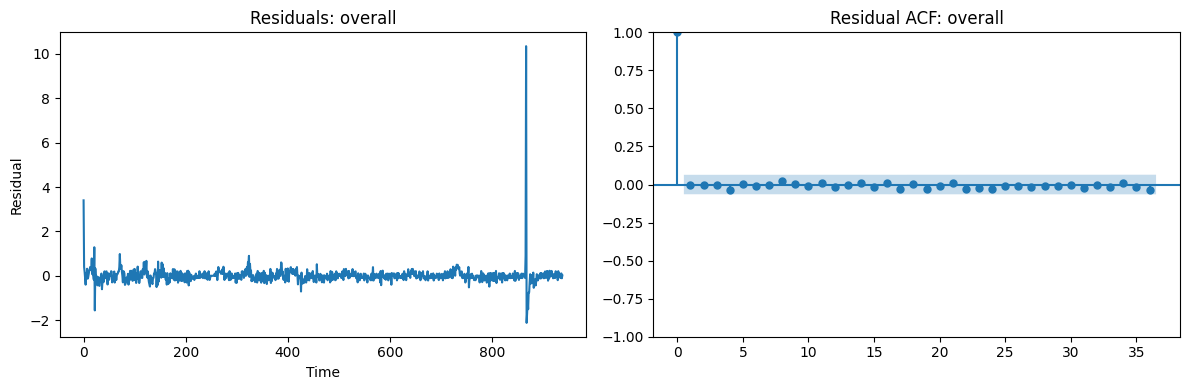

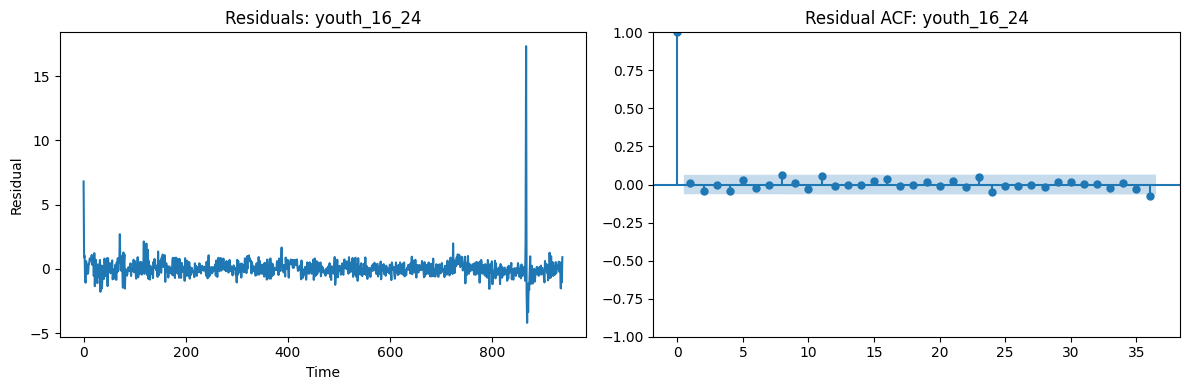

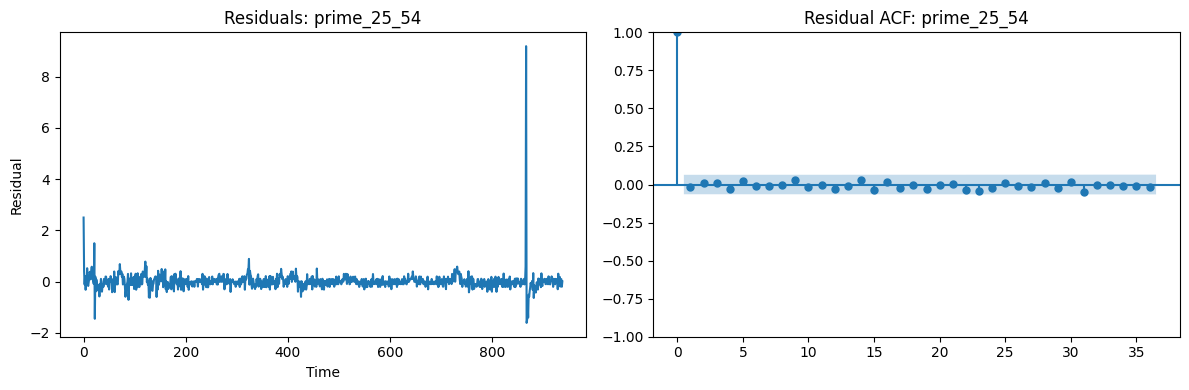

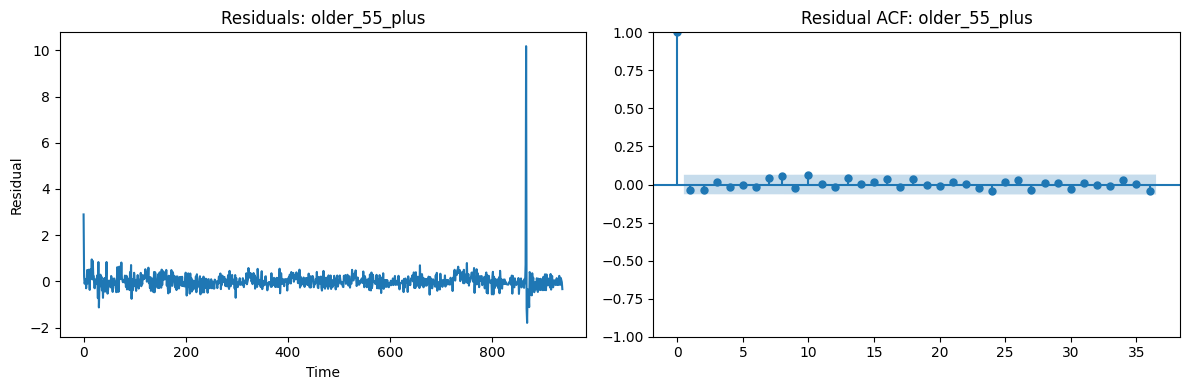

In [13]:

for col, item in arima_results.items():
    res = item["result"]
    resid = res.resid.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(resid)
    axes[0].set_title(f"Residuals: {col}")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Residual")
    
    plot_acf(resid, lags=36, ax=axes[1])
    axes[1].set_title(f"Residual ACF: {col}")
    
    plt.tight_layout()
    plt.show()

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test at selected lags
lb_rows = []

for col, item in arima_results.items():
    resid = item["result"].resid.dropna()
    
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    
    for lag in lb.index:
        lb_rows.append({
            "series": col,
            "lag": lag,
            "lb_stat": lb.loc[lag, "lb_stat"],
            "lb_pvalue": lb.loc[lag, "lb_pvalue"]
        })

ljung_box_df = pd.DataFrame(lb_rows)
print(ljung_box_df)

          series  lag    lb_stat  lb_pvalue
0        overall   12   2.216311   0.998995
1        overall   24   6.650543   0.999817
2    youth_16_24   12  12.102969   0.437446
3    youth_16_24   24  19.957353   0.699199
4    prime_25_54   12   3.643763   0.989041
5    prime_25_54   24  10.974672   0.989191
6  older_55_plus   12  12.260714   0.424975
7  older_55_plus   24  18.945106   0.754911


**Scientific Interpretation**

We began with a small set of low-order ARIMA models motivated by the ACF/PACF diagnostics, which suggested that differencing removed most of the serial dependence. The ARIMA results indicate that the same general dynamic specification fits all four unemployment series well. Among the candidate models considered, ARIMA(1,1,1) had the lowest AIC and BIC for the overall, youth, prime-age, and older-worker unemployment rates. This suggests that once the series are differenced, a relatively simple model with both autoregressive and moving-average terms is sufficient to capture their remaining short-run dependence.

The residual diagnostics support this choice. In all four series, the residuals are centered roughly around zero and do not show clear systematic patterns over time, aside from a few large isolated spikes. The residual ACF plots show that nearly all residual autocorrelations are small and lie within the confidence bands, indicating that little serial dependence remains after fitting the model. The Ljung–Box test shows that at both lag 12 and lag 24, the p-values are large for every series, so there is no evidence of remaining autocorrelation over one-year or two-year horizons.

Together, these results suggest that ARIMA(1,1,1) provides an adequate description of the short-run linear dependence structure in all four unemployment series. Large outliers associated with extreme macroeconomic events, especially around the COVID period, are not surprising for a simple ARIMA model. Overall, the ARIMA analysis suggests that the four unemployment series are more similar than different in their basic time-domain dependence once persistence in levels has been removed through differencing.

## Time-lagged Regression

Next, we turn to time-lagged regression to examine the dynamic relationships across unemployment series more directly. While the spectral analysis and ARIMA modeling focus on each series individually, time-lagged regression allows us to test whether changes in one age group’s unemployment rate are systematically associated with recent changes in another. The goal of this section is to assess whether monthly changes in youth unemployment are associated with contemporaneous or lagged changes in other unemployment series.

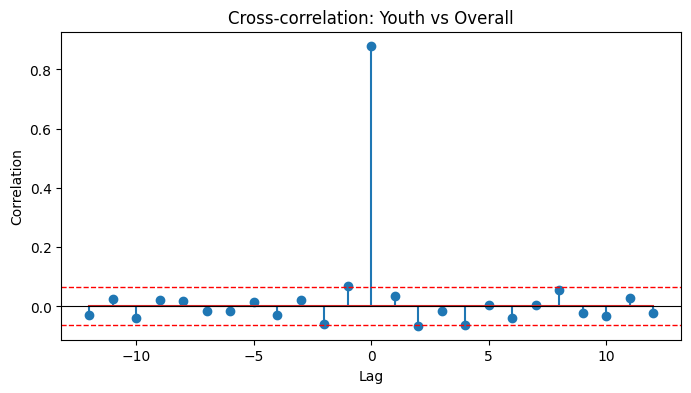

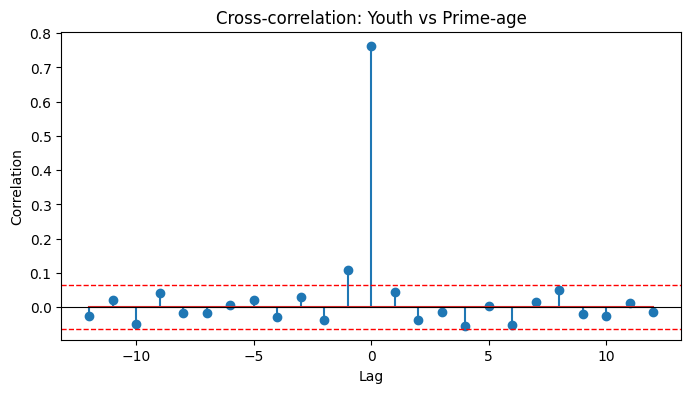

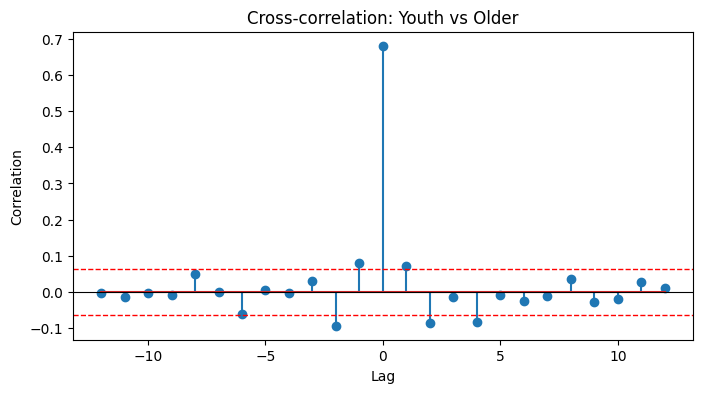

In [15]:
def cross_corr_values(x, y, max_lag=12):
    """
    Compute cross-correlations for lags from -max_lag to max_lag.
    
    Positive lag: y leads x
    Negative lag: x leads y
    """
    x = np.asarray(x.dropna())
    y = np.asarray(y.dropna())
    
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    
    lags = np.arange(-max_lag, max_lag + 1)
    corrs = []

    for lag in lags:
        if lag < 0:
            corr = np.corrcoef(x[:lag], y[-lag:])[0, 1]
        elif lag > 0:
            corr = np.corrcoef(x[lag:], y[:-lag])[0, 1]
        else:
            corr = np.corrcoef(x, y)[0, 1]
        corrs.append(corr)

    return lags, np.array(corrs)

def plot_cross_corr(x, y, x_name, y_name, max_lag=12):
    lags, corrs = cross_corr_values(x, y, max_lag=max_lag)
    conf = 1.96 / np.sqrt(len(x.dropna()))

    plt.figure(figsize=(8, 4))
    plt.stem(lags, corrs)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axhline(conf, color="red", linestyle="--", linewidth=1)
    plt.axhline(-conf, color="red", linestyle="--", linewidth=1)
    plt.title(f"Cross-correlation: {x_name} vs {y_name}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.show()

# youth vs overall
plot_cross_corr(
    df_diff["youth_16_24"],
    df_diff["overall"],
    "Youth",
    "Overall",
    max_lag=12
)

# youth vs prime-age
plot_cross_corr(
    df_diff["youth_16_24"],
    df_diff["prime_25_54"],
    "Youth",
    "Prime-age",
    max_lag=12
)

# youth vs older
plot_cross_corr(
    df_diff["youth_16_24"],
    df_diff["older_55_plus"],
    "Youth",
    "Older",
    max_lag=12
)

The cross-correlation plots show that changes in youth unemployment are most strongly related to contemporaneous changes in the other unemployment series, especially the overall and prime-age rates. There is little evidence of a strong or systematic lead-lag pattern beyond lag 0. Accordingly, the time-lagged regression analysis will focus on models with youth unemployment changes as the outcome and only a small number of current and recent lags from the comparison series.

In [16]:
import statsmodels.api as sm

def fit_lagged_regression(df_diff, y_col, x_col, max_lag=3):
    reg_df = df_diff[[y_col, x_col]].copy()

    for lag in range(max_lag + 1):
        reg_df[f"{x_col}_lag{lag}"] = reg_df[x_col].shift(lag)

    reg_df = reg_df.dropna()

    X_cols = [f"{x_col}_lag{lag}" for lag in range(max_lag + 1)]
    X = sm.add_constant(reg_df[X_cols])
    y = reg_df[y_col]

    model = sm.OLS(y, X).fit()
    return model, reg_df

lag_models = {}

comparisons = [
    "overall",
    "prime_25_54",
    "older_55_plus"
]

for x_col in comparisons:
    model, reg_df = fit_lagged_regression(
        df_diff=df_diff,
        y_col="youth_16_24",
        x_col=x_col,
        max_lag=3
    )
    lag_models[x_col] = {
        "model": model,
        "data": reg_df
    }

for x_col, item in lag_models.items():
    print(f"\n--- Youth on {x_col} lags 0 to 3 ---")
    print(item["model"].summary())


--- Youth on overall lags 0 to 3 ---
                            OLS Regression Results                            
Dep. Variable:            youth_16_24   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     810.2
Date:                Thu, 14 May 2026   Prob (F-statistic):          3.16e-301
Time:                        22:25:01   Log-Likelihood:                -414.12
No. Observations:                 935   AIC:                             838.2
Df Residuals:                     930   BIC:                             862.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const     

**Scientific Interpretation**
The time-lagged regressions indicate that changes in youth unemployment are explained primarily by contemporaneous changes in the other unemployment series, with only limited additional evidence of delayed effects.

The strongest relationship is between youth and the overall unemployment rate. The lag 0 coefficient is large and highly significant, and the model explains a substantial share of the variation in monthly youth unemployment changes with $R^2 \approx 0.78$. This suggests that when the overall unemployment rate changes in a given month, youth unemployment tends to move strongly in the same month as well. The lagged terms add little beyond this main contemporaneous association, although the coefficient on lag 3 is modestly negative and statistically significant, indicating a small delayed reversal after the initial co-movement.

The regression using prime-age unemployment shows a similar but somewhat weaker pattern. Again, the contemporaneous coefficient is large and highly significant, but the overall explanatory power is lower with $R^2 \approx 0.59$. None of the lagged prime-age terms is clearly significant at the $5\%$ level. This suggests that youth unemployment changes move closely with prime-age unemployment changes in the same month, but there is little evidence of an additional lagged relationship after the contemporaneous movement.

The model using older worker unemployment is again weaker overall with $R^2 \approx 0.48$ in terms of explanatory power, but it is the only one that shows a clearly significant positive lagged effect in addition to the contemporaneous term. Both lag 0 and lag 1 are positive and highly significant, which suggests that changes in older-worker unemployment are associated with same-month changes in youth unemployment and also one month later. 

Overall, these results are consistent with the cross-correlation plots that the dominant relationship is contemporaneous, especially for overall and prime-age unemployment. Youth unemployment changes appear to move most closely with the aggregate labor market as a whole, somewhat less with prime-age workers and older workers. The main exception is that the older-worker series shows some evidence of a positive one-month lagged association. 



## Conclusion

Using monthly U.S. unemployment rates for the overall labor force, youth workers, prime-age workers, and older workers, we compared these series through EDA, spectral analysis, ARIMA modeling, and time-lagged regression. The results suggest that unemployment dynamics across age groups are shaped more by shared macroeconomic conditions than by sharply different underlying time-series structures. 

All age groups share broad labor-market cycles, but youth unemployment stands out as consistently higher and more volatile than the others. The spectral analysis of first differences suggests that short-run unemployment changes are not driven by a single stable periodic cycle, but rather by irregular fluctuations and major macroeconomic shocks, with youth showing the strongest short-run variation. The ARIMA results indicate that the four series have broadly similar short-run dependence structures after differencing, and the residual diagnostics suggest that low-order ARIMA models capture that dependence reasonably well. Finally, the time-lagged regressions show that youth unemployment changes are most strongly related to contemporaneous changes in the overall and prime-age unemployment rates, with relatively limited evidence of strong delayed effects.

The COVID shock in 2020 is especially important as it appears as a major outlier in the descriptive plots, dominates parts of the spectral analysis, and remains visible in the ARIMA residuals. It demonstrates that this period was an unusually large disruption rather than ordinary cyclical variation.

These findings suggest that differences across age groups are less about fundamentally different dynamic mechanisms and more about the how impactful common labor-market shocks are. This is consistent with the real-world pattern that younger workers tend to be more exposed to recessions, hiring freezes, and sudden labor market disruptions.

## Acknowledgement



The methods and code implementation in this project were learned primarily from Professor Liberty Hamilton's lecture notes and in-class demonstrations, as well as from Time Series Analysis and Its Applications by Shumway and Stoffer. I am also grateful for the professor’s comment encouraging me to think more carefully about age heterogeneity in unemployment dynamics, which helped shape the final direction of the project.

In coding, large language models (LLM) were used in a limited capacity to assist with debugging code and brainstorming visualization ideas. In writing, LLM were used only for polishing, such as correcting grammar and spelling mistakes, and improving clarity at the paragraph level. No sections of the notebook were generated directly by an LLM.